0 0.6980658013842198
50 0.6776710265152973
100 0.6619383022441037
150 0.6497444788407983


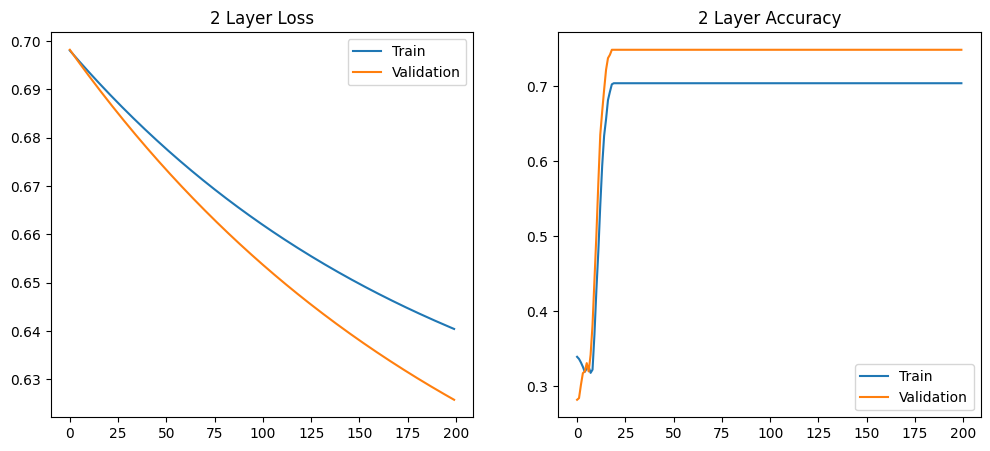

0 0.6931784585442182
50 0.674643383003449
100 0.6602327089116926
150 0.6489928766305307


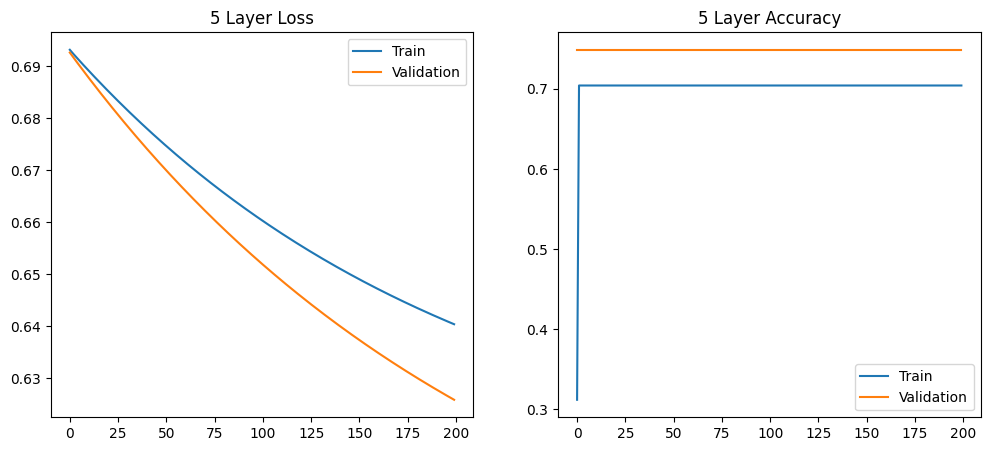

0 0.693147180676369
50 0.6746490272281868
100 0.6602408556081613
150 0.6490023954077428


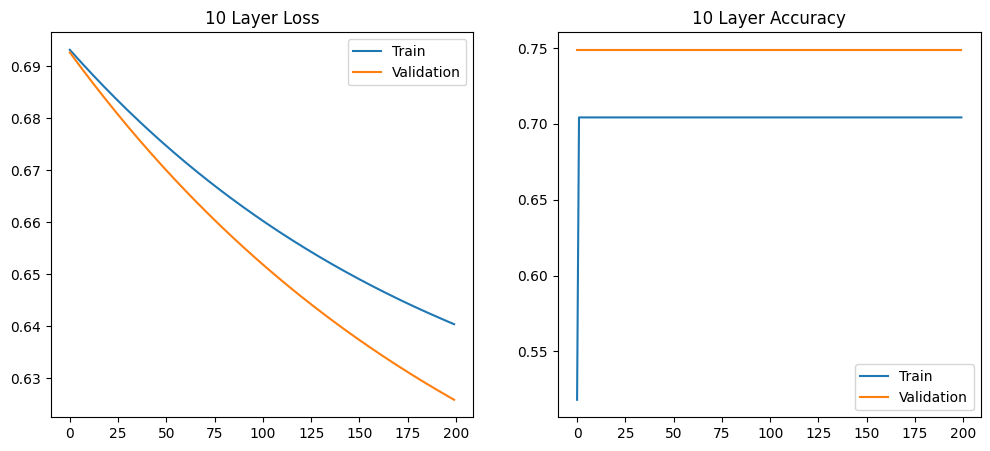

Test Loss: 0.6287035627151717
Test Accuracy: 0.74


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# DATASET

N = 3000

x1 = np.random.uniform(-2,2,N)
x2 = np.random.uniform(-2,2,N)

X = np.column_stack((x1,x2))
y = ((x1**2 + x2**2) > 1.5).astype(int).reshape(-1,1)

#SPLIT 70/15/15

indices = np.random.permutation(N)

train_end = int(0.7*N)
val_end = int(0.85*N)

train_idx = indices[:train_end]
val_idx = indices[train_end:val_end]
test_idx = indices[val_end:]

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]



epsilon = 1e-8

def sigmoid(z):
    return 1/(1+np.exp(-z))

def relu(z):
    return np.maximum(0,z)

def relu_grad(z):
    return (z>0).astype(float)

def sigmoid_grad(a):
    return a*(1-a)

def bce(y,y_hat):
    y_hat = np.clip(y_hat,epsilon,1-epsilon)
    return -np.mean(y*np.log(y_hat)+(1-y)*np.log(1-y_hat))

def accuracy(y,y_hat):
    preds = (y_hat>=0.5).astype(int)
    return np.mean(preds==y)

# MODEL INITIALIZATION

def init_model(layer_sizes):

    params = {}

    for l in range(len(layer_sizes)-1):

        params["W"+str(l+1)] = np.random.randn(layer_sizes[l],layer_sizes[l+1])*0.1
        params["b"+str(l+1)] = np.zeros((1,layer_sizes[l+1]))

    return params



def forward(X,params,activation):

    cache = {}
    A = X
    L = len(params)//2

    for l in range(1,L):

        Z = A@params["W"+str(l)] + params["b"+str(l)]
        cache["Z"+str(l)] = Z

        if activation=="relu":
            A = relu(Z)
        else:
            A = sigmoid(Z)

        cache["A"+str(l)] = A

    ZL = A@params["W"+str(L)] + params["b"+str(L)]
    AL = sigmoid(ZL)

    cache["Z"+str(L)] = ZL
    cache["A"+str(L)] = AL

    return AL,cache

# BACKWARD

def backward(X,y,params,cache,activation):

    grads = {}
    m = X.shape[0]
    L = len(params)//2

    AL = cache["A"+str(L)]
    dZ = AL - y

    A_prev = cache["A"+str(L-1)]

    grads["dW"+str(L)] = (A_prev.T@dZ)/m
    grads["db"+str(L)] = np.sum(dZ,axis=0,keepdims=True)/m

    for l in reversed(range(1,L)):

        W_next = params["W"+str(l+1)]
        dA = dZ@W_next.T

        Z = cache["Z"+str(l)]

        if activation=="relu":
            dZ = dA*relu_grad(Z)
        else:
            A = cache["A"+str(l)]
            dZ = dA*sigmoid_grad(A)

        A_prev = X if l==1 else cache["A"+str(l-1)]

        grads["dW"+str(l)] = (A_prev.T@dZ)/m
        grads["db"+str(l)] = np.sum(dZ,axis=0,keepdims=True)/m

    return grads

#  OPTIMIZERS

def update_sgd(params,grads,lr):

    L = len(params)//2

    for l in range(1,L+1):

        params["W"+str(l)] -= lr*grads["dW"+str(l)]
        params["b"+str(l)] -= lr*grads["db"+str(l)]

    return params

def update_momentum(params,grads,velocity,lr,beta=0.9):

    L = len(params)//2

    for l in range(1,L+1):

        velocity["dW"+str(l)] = beta*velocity["dW"+str(l)] + lr*grads["dW"+str(l)]
        velocity["db"+str(l)] = beta*velocity["db"+str(l)] + lr*grads["db"+str(l)]

        params["W"+str(l)] -= velocity["dW"+str(l)]
        params["b"+str(l)] -= velocity["db"+str(l)]

    return params,velocity

# TRAIN

def train(layer_sizes,activation="relu",optimizer="sgd",epochs=200,lr=0.01):

    params = init_model(layer_sizes)

    velocity = {}

    if optimizer=="momentum":

        for l in range(1,len(layer_sizes)):
            velocity["dW"+str(l)] = np.zeros_like(params["W"+str(l)])
            velocity["db"+str(l)] = np.zeros_like(params["b"+str(l)])

    train_losses,val_losses = [],[]
    train_accs,val_accs = [],[]

    for epoch in range(epochs):

        y_hat,cache = forward(X_train,params,activation)

        loss = bce(y_train,y_hat)

        grads = backward(X_train,y_train,params,cache,activation)

        if optimizer=="sgd":
            params = update_sgd(params,grads,lr)
        else:
            params,velocity = update_momentum(params,grads,velocity,lr)

        y_val_hat,_ = forward(X_val,params,activation)

        train_losses.append(loss)
        val_losses.append(bce(y_val,y_val_hat))

        train_accs.append(accuracy(y_train,y_hat))
        val_accs.append(accuracy(y_val,y_val_hat))

        if epoch%50==0:
            print(epoch,loss)

    return params,train_losses,val_losses,train_accs,val_accs

#  PLOTS

def plot_metrics(train_losses,val_losses,train_accs,val_accs,title):

    epochs = len(train_losses)

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(train_losses,label="Train")
    plt.plot(val_losses,label="Validation")
    plt.title(title+" Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(train_accs,label="Train")
    plt.plot(val_accs,label="Validation")
    plt.title(title+" Accuracy")
    plt.legend()

    plt.show()

# RUN MODELS

# 2 layer
params,tl,vl,ta,va = train([2,4,1],"relu","sgd")
plot_metrics(tl,vl,ta,va,"2 Layer")

# 5 layer
params,tl,vl,ta,va = train([2,4,4,4,4,1],"relu","sgd")
plot_metrics(tl,vl,ta,va,"5 Layer")

# 10 layer
params,tl,vl,ta,va = train([2,4,4,4,4,4,4,4,4,4,1],"relu","sgd")
plot_metrics(tl,vl,ta,va,"10 Layer")

# TEST EVALUATION

y_test_hat,_ = forward(X_test,params,"relu")

print("Test Loss:",bce(y_test,y_test_hat))
print("Test Accuracy:",accuracy(y_test,y_test_hat))